## Data Insights


This notebook loads `data/processed/publication_data.csv`, produced by `00_data_processing.ipynb`.

In [41]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import plotly.graph_objects as go
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from IPython.display import HTML

HTML("""
<style>
@import url('https://fonts.googleapis.com/css2?family=Libre+Baskerville:wght@400;700&family=Libre+Franklin:wght@400;500;600;700&display=swap');
</style>
""")

In [42]:
merged_data = pd.read_csv("../data/processed/publication_data.csv")

wdi_cols = [c for c in merged_data.columns if c not in
            ['iso_alpha', 'Year', 'Publications', 'Country', 'data_source_flag']]
years_with_wdi = merged_data.loc[merged_data[wdi_cols].notna().any(axis=1), 'Year']

print(f"Country-year rows: {len(merged_data)}")
print(f"Distinct countries: {merged_data['Country'].nunique()}")
print(f"Years: {merged_data['Year'].min()}-{merged_data['Year'].max()}")
print(f"Years with WDI coverage: {years_with_wdi.min()}-{years_with_wdi.max()} ({years_with_wdi.nunique()} years)")

Country-year rows: 4020
Distinct countries: 201
Years: 2003-2022
Years with WDI coverage: 2003-2022 (20 years)


Window: 2016 - 2022. OSF published reproducibility crisis in 2015, and covid began 2019. This window attempts to capture psych post-reproducibility-crisis-awareness and the landscape pre-covid.

In [43]:
time_interval = merged_data[merged_data['Year'].between(2016, 2022)]

mean_cols = [
    'GDP_per_capita', 'GNI_per_capita_PPP', 'Population', 'Tertiary_enrollment_pct',
    'RnD_expenditure_pct', 'Researchers_per_million',
    'Education_expenditure_pct', 'Tertiary_education_expenditure_pct',
    'Urban_population_pct', 'Sci_tech_articles', 'Internet_users_pct',
]

country_summary = time_interval.groupby(['iso_alpha', 'Country'], as_index=False).agg(
    Publications=('Publications', 'sum'),
    SE_articles_total_subset=('SE_articles_total', lambda x: x.sum(min_count=1)),
    data_source_flag=('data_source_flag', 'first'),
    **{col: (col, 'mean') for col in mean_cols},
)

country_summary['psych_share'] = country_summary['Publications'] / country_summary['SE_articles_total_subset']
country_summary['log_publications'] = np.log1p(country_summary['Publications'])

print(f"Countries in 2016-2022 summary: {len(country_summary)}")
print(f"Total psychology publications (2016-2022): {country_summary['Publications'].sum():,.0f}")

Countries in 2016-2022 summary: 201
Total psychology publications (2016-2022): 388,583


### Global distribution, mapped

In [44]:
nonzero = country_summary['Publications'] > 0
q1, q2, q3 = country_summary.loc[nonzero, 'Publications'].quantile([0.25, 0.5, 0.75])
median = country_summary['Publications'].median()
plot_min = country_summary['Publications'].min()
plot_max = country_summary['Publications'].max()

print(f"zero contributions share: {(~nonzero).mean():.2%}")
print(f"min: {plot_min}, q1: {q1}, median (all): {median}, q2 (nonzero): {q2}, q3: {q3}, max: {plot_max}")

country_summary['quartile'] = 'Zero publications'
country_summary.loc[nonzero, 'quartile'] = pd.qcut(
    country_summary.loc[nonzero, 'Publications'], q=4, labels=['Q1', 'Q2', 'Q3', 'Q4']
)

print(country_summary['quartile'].value_counts())

top_quartile = country_summary.sort_values('Publications', ascending=False)
bottom_quartile = country_summary[country_summary['Publications'] > 0].sort_values('Publications')

print(f"\nTop 5 contributors:\n{top_quartile.iloc[:5, :3]}")
print(f"\nBottom 5 contributors, non-zero:\n{bottom_quartile.iloc[:5, :3]}")

top_5 = top_quartile.iloc[:5, 0].tolist()

zero contributions share: 7.96%
min: 0.0, q1: 5.18, median (all): 26.0, q2 (nonzero): 39.54, q3: 559.67, max: 123318.51
quartile
Q1                   47
Q2                   46
Q3                   46
Q4                   46
Zero publications    16
Name: count, dtype: int64

Top 5 contributors:
    iso_alpha         Country  Publications
188       USA   United States     123318.51
62        GBR  United Kingdom      29975.06
45        DEU         Germany      24571.98
32        CHN           China      23294.01
29        CAN          Canada      18402.68

Bottom 5 contributors, non-zero:
    iso_alpha        Country  Publications
182       TUV         Tuvalu          0.05
39        COM        Comoros          0.20
67        GNB  Guinea-Bissau          0.29
110       MDA        Moldova          0.31
1         AGO         Angola          0.40


### US-specific

In [45]:
world_total = country_summary['Publications'].sum()
us = country_summary.loc[country_summary['Country'] == 'United States', 'Publications'].values[0]
print(f"world total: {world_total:,.0f}")
print(f"US share: {us / world_total:.1%}")

world_pop = country_summary['Population'].sum()
us_pop = country_summary.loc[country_summary['Country'] == 'United States', 'Population'].values[0]
print(f"US share of population: {us_pop / world_pop:.1%}")

non_us = country_summary[country_summary['Country'] != 'United States'].sort_values('Publications', ascending=False)
runner_up = non_us.iloc[0]
print(f"US is {us / runner_up['Publications']:.1f}x {runner_up['Country']} (#2)")

world total: 388,583
US share: 31.7%
US share of population: 4.2%
US is 4.1x United Kingdom (#2)


### Change over time

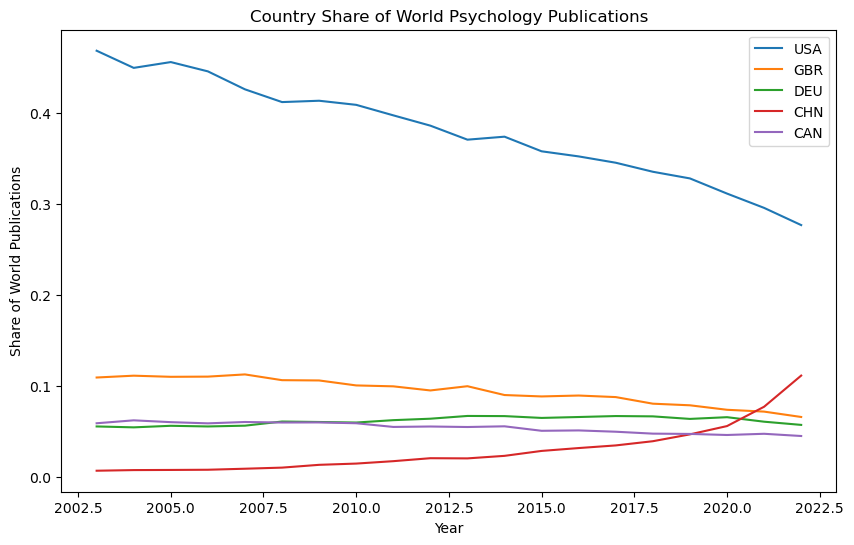

In [46]:
panel_cy = merged_data.groupby(['iso_alpha', 'Year'], as_index=False)['Publications'].sum()

world_by_year = panel_cy.groupby('Year')['Publications'].sum()
panel_cy = panel_cy.merge(world_by_year.rename('world_total'), left_on='Year', right_index=True)
panel_cy['share_of_world'] = panel_cy['Publications'] / panel_cy['world_total']

plt.figure(figsize=(10, 6))
for code in top_5:
    subset = panel_cy[panel_cy['iso_alpha'] == code]
    plt.plot(subset['Year'], subset['share_of_world'], label=code)

plt.xlabel('Year')
plt.ylabel('Share of World Publications')
plt.title('Country Share of World Psychology Publications')
plt.legend()
plt.show()

### Predictors

In [53]:
base = country_summary.dropna(subset=['SE_articles_total_subset']).copy()
print(base[['Publications', 'SE_articles_total_subset', 'psych_share']].describe().round(4).to_string())

       Publications  SE_articles_total_subset  psych_share
count      201.0000              2.010000e+02     201.0000
mean      1933.2467              9.834426e+04       0.0139
std       9494.8390              4.043803e+05       0.0121
min          0.0000              7.700000e-01       0.0000
25%          3.1400              2.948800e+02       0.0046
50%         26.0000              2.793680e+03       0.0108
75%        401.7100              4.126694e+04       0.0197
max     123318.5100              4.393000e+06       0.0550


In [55]:
# Funnel diagnostic

base['granularity'] = 1 / base['SE_articles_total_subset']
base['den_decile'] = pd.qcut(base['SE_articles_total_subset'], 20, labels=False)

spread = base.groupby('den_decile').agg(
    n=('psych_share', 'size'),
    den_max=('SE_articles_total_subset', 'max'),
    granularity=('granularity', 'median'),
    share_sd=('psych_share', 'std'),
    share_iqr=('psych_share', lambda x: x.quantile(.75) - x.quantile(.25)),
).round(5)

spread['granularity_ratio'] = spread['granularity'] / spread['share_sd']

print(spread.to_string())

             n     den_max  granularity  share_sd  share_iqr  granularity_ratio
den_decile                                                                     
0           11       28.16      0.06770   0.00593    0.00000          11.416526
1           10       70.17      0.02302   0.01784    0.02100           1.290359
2           10      118.62      0.01028   0.00794    0.00978           1.294710
3           10      204.68      0.00678   0.01773    0.02579           0.382403
4           10      294.88      0.00401   0.00587    0.00279           0.683135
5           10      523.94      0.00236   0.01340    0.01063           0.176119
6           10      987.81      0.00151   0.00968    0.00909           0.155992
7           10     1318.18      0.00086   0.00681    0.00947           0.126285
8           10     1767.25      0.00059   0.00735    0.00998           0.080272
9           10     2793.68      0.00050   0.00758    0.00575           0.065963
10          10     4250.19      0.00030 